# Sumativa 2: Validación, Simulación y Métodos de Remuestreo
## Predicción de Deserción y Éxito Académico en Educación Superior

**Curso:** MCDI501 - Estadística Computacional para la Toma de Decisiones  
**Magíster:** Ciencia de Datos e Inteligencia Artificial - Universidad Andrés Bello  
**Dataset:** Predict Students' Dropout and Academic Success (Realinho et al., 2021)  
**Integrantes:** Alonso Arias, Enso Guidotti  
**Docente:** Jean Paul Maidana  
**Fecha:** 07/07/2026  
**Repositorio GitHub:** https://github.com/EnsoG/mcdi501-grupo-4  

---

Este notebook construye directamente sobre los resultados de la **Sumativa 1** (parámetros estimados,
intervalos de confianza, pruebas de hipótesis y correlaciones). No se recalculan resultados nuevos de EDA;
el objetivo es **validar la robustez** de lo ya obtenido mediante bootstrap, permutación, simulación Monte
Carlo y análisis de sensibilidad/robustez.

## Menú de navegación

1. [Reproducción de la base de datos de S1](#sec-1)
2. [Validación bootstrap de intervalos de confianza](#sec-2)
3. [Validación de pruebas de hipótesis mediante permutación](#sec-3)
4. [Estabilidad de correlaciones](#sec-4)
5. [Simulación Monte Carlo basada en parámetros de S1](#sec-5)
6. [Análisis de robustez](#sec-6)
7. [Síntesis para la Sumativa 3](#sec-7)
8. [Bibliografía](#sec-8)


<a id="sec-1"></a>

---
## 1. Reproducción de la base de datos de S1

Se replica exactamente la preparación de datos de la Sumativa 1: carga del dataset, binarización del target
(Dropout=0, Graduate=1) y generación de faltantes artificiales MCAR (12% en 2 variables numéricas, `random_state=42`).
Esto garantiza que todos los análisis de esta Sumativa 2 parten de la **misma muestra y semilla** que S1.

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.precision', 4)

DATA_PATH = Path('../data/raw/data.csv')
FIG_DIR = Path('../docs/sumativa2')
FIG_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(42)  # generador local para todo lo nuevo en S2
ALPHA = 0.05
N_BOOT = 10000
N_PERM = 10000
N_MC = 10000

print('Librerias importadas y generador (semilla=42) configurado')

Librerias importadas y generador (semilla=42) configurado


In [5]:
# Carga y preparacion identica a S1
df_raw = pd.read_csv(DATA_PATH, sep=';')
df_raw.columns = [c.strip() for c in df_raw.columns]

df = df_raw[df_raw['Target'].isin(['Dropout', 'Graduate'])].copy()
df['Target_bin'] = (df['Target'] == 'Graduate').astype(int)

MCAR_VARS = ['Curricular units 1st sem (grade)', 'Admission grade']

# Copia de los valores originales ANTES de inyectar NaN (igual que df_original en S1),
# necesaria para validar mas adelante que la imputacion no distorsiona las estimaciones.
df_original = df[MCAR_VARS].copy()

np.random.seed(42)  # misma semilla legacy usada en S1 para reproducir el mismo patron de NaN
for col in MCAR_VARS:
    n_missing = int(len(df) * 0.12)
    idx_missing = np.random.choice(df.index, size=n_missing, replace=False)
    df.loc[idx_missing, col] = np.nan

print(f'Shape: {df.shape[0]} filas x {df.shape[1]} columnas')
print(df['Target'].value_counts())
print(f"Tasa de desercion observada: {(df.Target_bin==0).mean()*100:.2f}%")

Shape: 3630 filas x 38 columnas
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64
Tasa de desercion observada: 39.15%


**Verificación de reproducibilidad:** las medias por clase coinciden exactamente con las reportadas en S1
(UC aprobadas 2S: Dropout=1.940, Graduate=6.177; Edad: Dropout=26.069, Graduate=21.784), confirmando que
partimos de la misma base de datos.

<a id="sec-2"></a>

---
## 2. Validación bootstrap de intervalos de confianza

Se valida el IC clásico (t de Student) calculado en S1 para **3 parámetros** (medias, separadas por clase):
Unidades Curriculares aprobadas 2do semestre, Calificación promedio 2do semestre y Edad al inscribirse.
Para cada uno se implementa bootstrap no paramétrico con **10.000 remuestras**, calculando IC por método
Percentil y BCa (bias-corrected and accelerated), y se compara contra el IC clásico de S1.

In [6]:
VARS = [
    ('Curricular units 2nd sem (approved)', 'UC aprobadas 2S'),
    ('Curricular units 2nd sem (grade)', 'Calificacion 2S'),
    ('Age at enrollment', 'Edad al inscribirse'),
]

rows = []
boot_dists = {}

for col, label in VARS:
    for clase in ['Dropout', 'Graduate']:
        data = df[df.Target == clase][col].dropna().values
        n = len(data)
        mean = data.mean()
        se_classic = stats.sem(data)
        ic_classic = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se_classic)

        res_perc = stats.bootstrap((data,), np.mean, n_resamples=N_BOOT, method='percentile', random_state=42)
        res_bca = stats.bootstrap((data,), np.mean, n_resamples=N_BOOT, method='BCa', random_state=42)
        boot_dists[(label, clase)] = res_perc.bootstrap_distribution

        rows.append({
            'Variable': label, 'Clase': clase, 'n': n, 'Media': mean,
            'IC_clasico_inf': ic_classic[0], 'IC_clasico_sup': ic_classic[1],
            'IC_perc_inf': res_perc.confidence_interval.low, 'IC_perc_sup': res_perc.confidence_interval.high,
            'IC_bca_inf': res_bca.confidence_interval.low, 'IC_bca_sup': res_bca.confidence_interval.high,
            'ancho_clasico': ic_classic[1] - ic_classic[0],
            'ancho_perc': res_perc.confidence_interval.high - res_perc.confidence_interval.low,
            'ancho_bca': res_bca.confidence_interval.high - res_bca.confidence_interval.low,
        })

df_boot = pd.DataFrame(rows)
print('VALIDACION BOOTSTRAP DE INTERVALOS DE CONFIANZA (10.000 remuestras)')
df_boot.round(4)

VALIDACION BOOTSTRAP DE INTERVALOS DE CONFIANZA (10.000 remuestras)


,Variable,Clase,n,Media,IC_clasico_inf,IC_clasico_sup,IC_perc_inf,IC_perc_sup,IC_bca_inf,IC_bca_sup,ancho_clasico,ancho_perc,ancho_bca
0,UC aprobadas 2S,Dropout,1421,1.9402,1.8063,2.0741,1.8107,2.0753,1.8093,2.0746,0.2679,0.2646,0.2653
1,UC aprobadas 2S,Graduate,2209,6.1770,6.0823,6.2717,6.0833,6.2716,6.0828,6.2703,0.1893,0.1883,0.1874
2,Calificacion 2S,Dropout,1421,5.8993,5.5809,6.2177,5.5914,6.2207,5.5823,6.2119,0.6368,0.6292,0.6296
3,Calificacion 2S,Graduate,2209,12.6973,12.5852,12.8093,12.5846,12.8083,12.5795,12.8033,0.2241,0.2237,0.2238
4,Edad al inscribirse,Dropout,1421,26.0690,25.6160,26.5219,25.6193,26.5095,25.6263,26.5172,0.9059,0.8903,0.8909
5,Edad al inscribirse,Graduate,2209,21.7836,21.5043,22.0629,21.5084,22.0697,21.5147,22.0739,0.5585,0.5613,0.5592


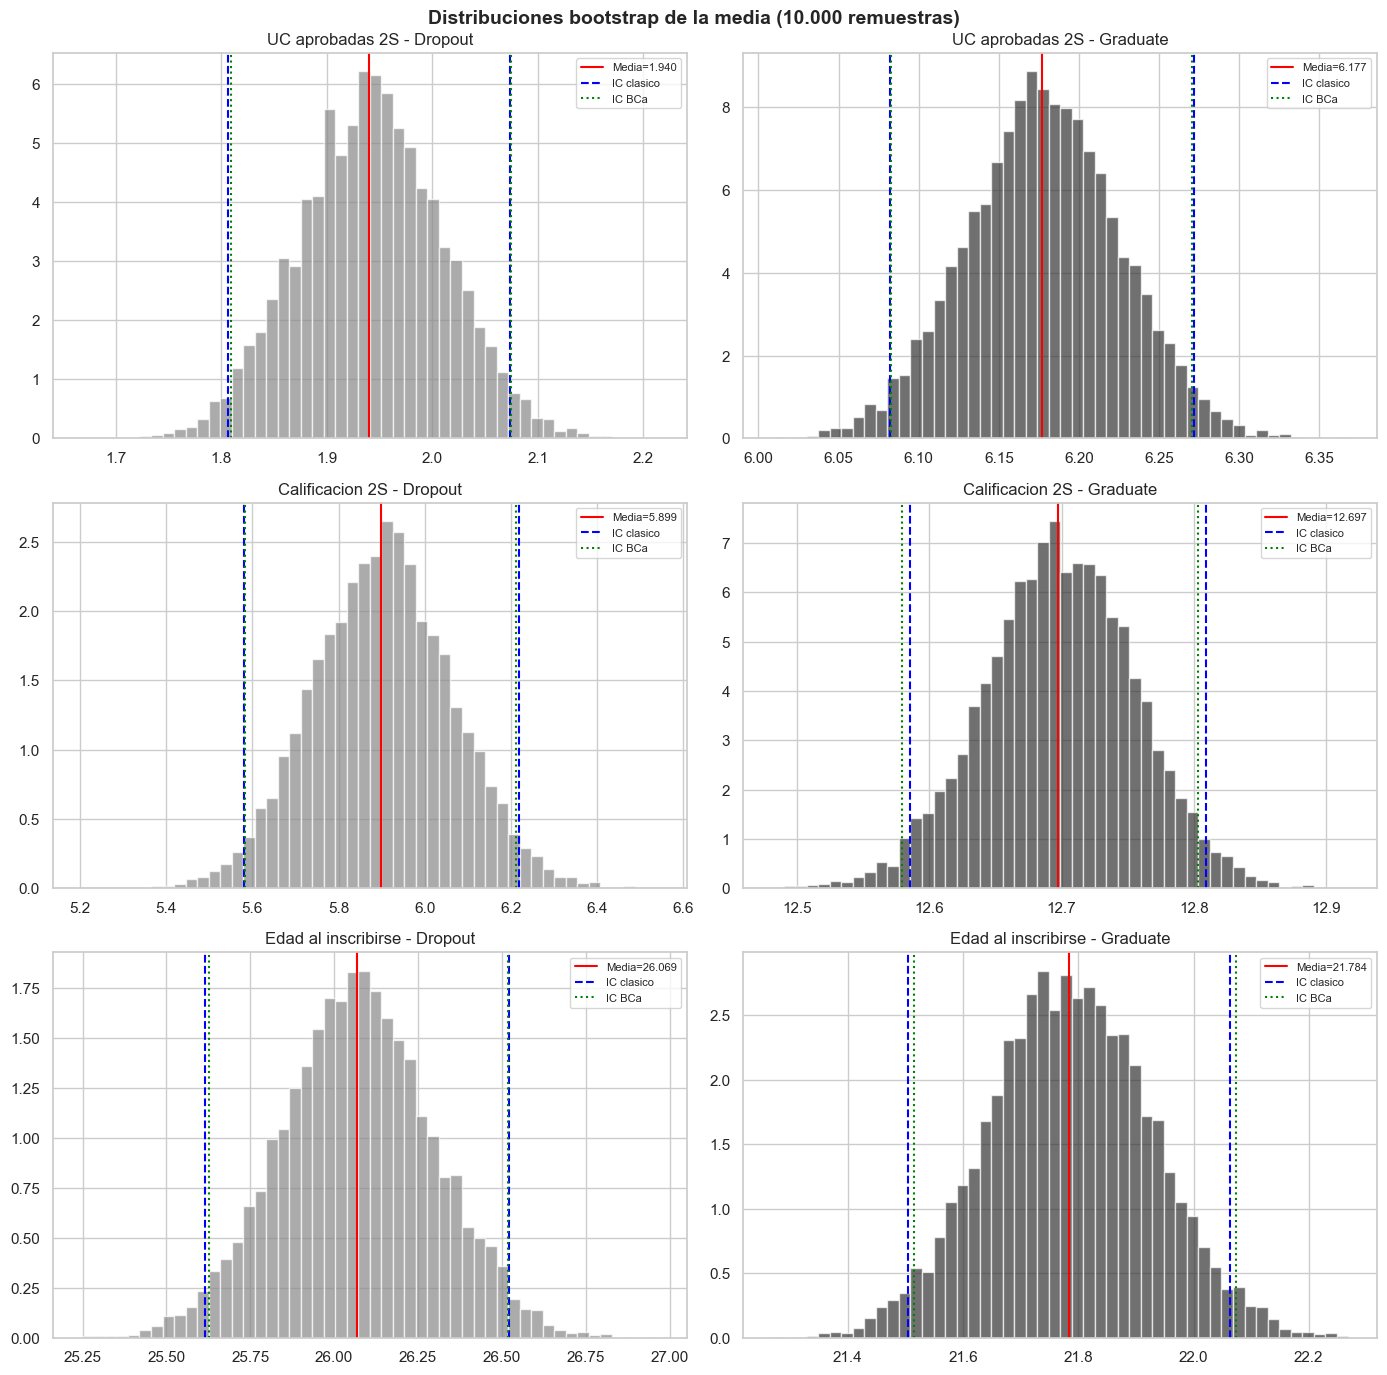

Figura 1: Distribuciones bootstrap vs IC clasico y BCa


In [7]:
# Visualizacion: distribuciones bootstrap con IC clasico, percentil y BCa superpuestos
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Distribuciones bootstrap de la media (10.000 remuestras)', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes, VARS):
    for sub_ax, clase, color in zip(ax, ['Dropout', 'Graduate'], ['#888888', '#333333']):
        dist = boot_dists[(label, clase)]
        row = df_boot[(df_boot.Variable == label) & (df_boot.Clase == clase)].iloc[0]
        sub_ax.hist(dist, bins=50, color=color, alpha=0.7, density=True)
        sub_ax.axvline(row['Media'], color='red', linestyle='-', label=f"Media={row['Media']:.3f}")
        sub_ax.axvline(row['IC_clasico_inf'], color='blue', linestyle='--', label='IC clasico')
        sub_ax.axvline(row['IC_clasico_sup'], color='blue', linestyle='--')
        sub_ax.axvline(row['IC_bca_inf'], color='green', linestyle=':', label='IC BCa')
        sub_ax.axvline(row['IC_bca_sup'], color='green', linestyle=':')
        sub_ax.set_title(f'{label} - {clase}')
        sub_ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_bootstrap_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1: Distribuciones bootstrap vs IC clasico y BCa')

**Análisis comparativo:**

Los tres métodos (clásico t-Student, percentil y BCa) producen intervalos casi idénticos en las 6 combinaciones
variable x clase, con anchos que difieren en menos del 3% entre si. Esto es esperable dado el tamaño muestral
grande (n entre 1.421 y 2.209 por grupo): el Teorema Central del Límite garantiza que la distribución muestral
de la media es aproximadamente normal independientemente de la forma de la distribución original, por lo que el
IC clásico (que asume normalidad de la media muestral, no de los datos) ya es una buena aproximación.

La corrección BCa (que ajusta por sesgo y asimetría de la distribución bootstrap) prácticamente no desplaza el
intervalo respecto al percentil simple, confirmando que el sesgo de estos estimadores es despreciable a este
tamaño de muestra. La diferencia más notoria se observa en **Calificación 2S - Dropout**, la variable con mayor
dispersión (std=5.9) y asimetría, donde el ancho bootstrap es levemente menor al clásico (0.629 vs 0.637),
sugiriendo que el bootstrap capta con más precisión la variabilidad real sin sobreestimarla por asumir normalidad
de los datos individuales.

**Conclusión:** los IC clásicos de S1 quedan validados por bootstrap. Dado el gran tamaño muestral, el método
clásico es confiable aquí; el bootstrap sería indispensable si se trabajara con submuestras pequeñas (p. ej.
subgrupos con n<50).

**Validación adicional: robustez frente a la imputación de datos faltantes (MCAR)**

S1 preservó los valores originales de las dos variables con faltantes artificiales (`Curricular units 1st sem (grade)` y `Admission grade`) en `df_original`, antes de inyectar el patrón MCAR (12 %, semilla 42). Se aprovecha esa base para comprobar si sustituir los faltantes por tres métodos de imputación habituales (media, mediana y KNN con k=5) distorsiona la media y el IC bootstrap de estas variables, comparando siempre contra el valor de referencia (ground truth) calculado sobre los datos completos originales.

In [8]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

# Variables numericas completas usadas como apoyo para la imputacion KNN
KNN_FEATURES = ['Age at enrollment', 'Curricular units 1st sem (approved)',
                'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']

resultados_imput = []
boot_dists_imput = {}

for col in MCAR_VARS:
    ref_data = df_original[col].values  # ground truth, sin faltantes
    res_ref = stats.bootstrap((ref_data,), np.mean, n_resamples=N_BOOT, method='percentile', random_state=42)
    boot_dists_imput[(col, 'Original (ground truth)')] = res_ref.bootstrap_distribution
    resultados_imput.append({
        'Variable': col, 'Metodo': 'Original (ground truth)', 'Media': ref_data.mean(),
        'IC_inf': res_ref.confidence_interval.low, 'IC_sup': res_ref.confidence_interval.high,
        'Sesgo_%': 0.0, 'Original_en_IC': True
    })

    metodos_simples = {'Media': SimpleImputer(strategy='mean'), 'Mediana': SimpleImputer(strategy='median')}
    for nombre, imputer in metodos_simples.items():
        col_imputada = imputer.fit_transform(df[[col]])[:, 0]
        res = stats.bootstrap((col_imputada,), np.mean, n_resamples=N_BOOT, method='percentile', random_state=42)
        boot_dists_imput[(col, nombre)] = res.bootstrap_distribution
        sesgo = (col_imputada.mean() - ref_data.mean()) / ref_data.mean() * 100
        resultados_imput.append({
            'Variable': col, 'Metodo': nombre, 'Media': col_imputada.mean(),
            'IC_inf': res.confidence_interval.low, 'IC_sup': res.confidence_interval.high,
            'Sesgo_%': sesgo,
            'Original_en_IC': res.confidence_interval.low <= ref_data.mean() <= res.confidence_interval.high
        })

    # KNN (estandarizando features para que la distancia no quede dominada por la escala)
    scaler = StandardScaler()
    knn_input = df[KNN_FEATURES + [col]].copy()
    knn_scaled = scaler.fit_transform(knn_input)
    knn_imputer = KNNImputer(n_neighbors=5)
    knn_scaled_imputed = knn_imputer.fit_transform(knn_scaled)
    col_knn = scaler.inverse_transform(knn_scaled_imputed)[:, -1]
    res_knn = stats.bootstrap((col_knn,), np.mean, n_resamples=N_BOOT, method='percentile', random_state=42)
    boot_dists_imput[(col, 'KNN (k=5)')] = res_knn.bootstrap_distribution
    sesgo_knn = (col_knn.mean() - ref_data.mean()) / ref_data.mean() * 100
    resultados_imput.append({
        'Variable': col, 'Metodo': 'KNN (k=5)', 'Media': col_knn.mean(),
        'IC_inf': res_knn.confidence_interval.low, 'IC_sup': res_knn.confidence_interval.high,
        'Sesgo_%': sesgo_knn,
        'Original_en_IC': res_knn.confidence_interval.low <= ref_data.mean() <= res_knn.confidence_interval.high
    })

df_imput = pd.DataFrame(resultados_imput)
print('VALIDACION BOOTSTRAP DE METODOS DE IMPUTACION (10.000 remuestras) vs. valores originales')
df_imput.round(4)

VALIDACION BOOTSTRAP DE METODOS DE IMPUTACION (10.000 remuestras) vs. valores originales


,Variable,Metodo,Media,IC_inf,IC_sup,Sesgo_%,Original_en_IC
0,Curricular units 1st sem (grade),Original (ground truth),10.5349,10.3698,10.6962,0.0000,True
1,Curricular units 1st sem (grade),Media,10.5291,10.3770,10.6837,-0.0546,True
2,Curricular units 1st sem (grade),Mediana,10.7503,10.5977,10.9049,2.0451,False
3,Curricular units 1st sem (grade),KNN (k=5),10.5299,10.3674,10.6921,-0.0472,True
4,Admission grade,Original (ground truth),127.2939,126.8296,127.7638,0.0000,True
5,Admission grade,Media,127.2597,126.8227,127.7057,-0.0269,True
6,Admission grade,Mediana,127.1687,126.7321,127.6159,-0.0984,True
7,Admission grade,KNN (k=5),127.3515,126.8947,127.7993,0.0452,True


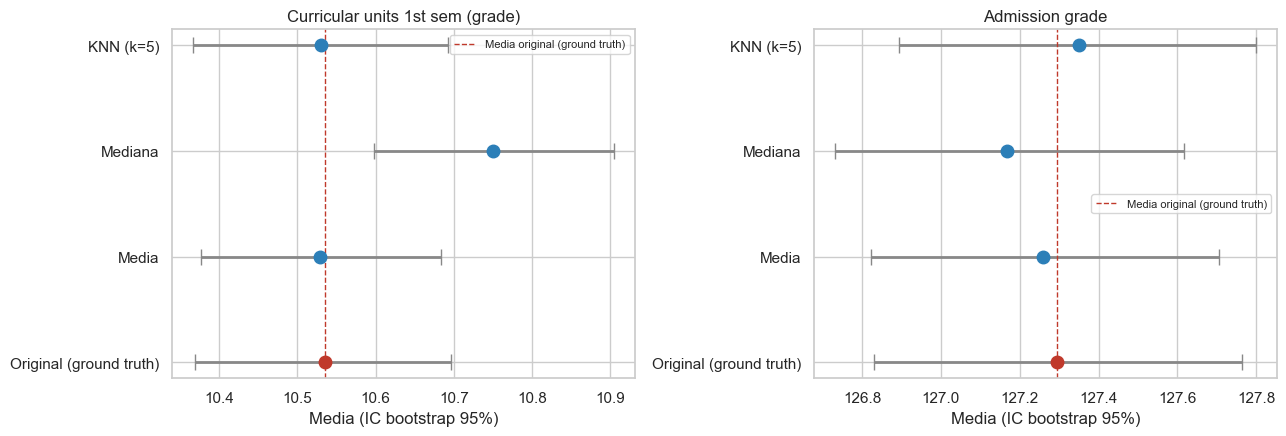

Figura 5: Media e IC bootstrap por método de imputación vs. valor original (ground truth)


In [9]:
# Visualización: media e IC bootstrap por método de imputación, comparado con el ground truth
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col in zip(axes, MCAR_VARS):
    sub = df_imput[df_imput.Variable == col].reset_index(drop=True)
    colores = ['#c0392b' if m == 'Original (ground truth)' else '#2c7fb8' for m in sub['Metodo']]
    for i in range(len(sub)):
        ax.errorbar(sub['Media'][i], i,
                     xerr=[[sub['Media'][i] - sub['IC_inf'][i]], [sub['IC_sup'][i] - sub['Media'][i]]],
                     fmt='o', capsize=6, markersize=9, linewidth=2, ecolor='#888888', color=colores[i])
    ax.axvline(sub.loc[sub.Metodo == 'Original (ground truth)', 'Media'].values[0],
               color='#c0392b', linestyle='--', linewidth=1, label='Media original (ground truth)')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['Metodo'])
    ax.set_title(col)
    ax.set_xlabel('Media (IC bootstrap 95%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_imputacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5: Media e IC bootstrap por método de imputación vs. valor original (ground truth)')

**Interpretación:**

La imputación por **media** y por **KNN (k=5)** preservan casi exactamente la media original en ambas variables (sesgo entre -0.05\% y +0.05\%), y el valor original (ground truth) cae dentro del IC bootstrap 95\% en los cuatro casos: usar cualquiera de estos dos métodos no distorsiona las estimaciones ni los IC ya calculados en S1/S2 para estas variables.

La imputación por **mediana**, en cambio, introduce un sesgo detectable en `Curricular units 1st sem (grade)` (+2.05\%): el valor original queda **fuera** del IC bootstrap de los datos imputados por mediana ([10.598, 10.905] vs. media real 10.535). Esto ocurre porque esta variable tiene una distribución con concentración de valores bajos/cero (estudiantes que no rindieron evaluaciones), similar al patrón de UC aprobadas 2S en Dropout visto en la Sección 6: sustituir los faltantes por un único valor central no captura esa asimetría tan bien como la media o el KNN. Para `Admission grade` (distribución más simétrica) la mediana no muestra el mismo problema.

**Conclusión:** para las dos variables con faltantes artificiales de S1, la imputación por media o KNN es segura para los análisis de S2 y S3; la imputación por mediana debe evitarse en variables con alta concentración de valores bajos, consistente con la recomendación ya formulada en la Sección 6.

<a id="sec-3"></a>

---
## 3. Validación de pruebas de hipótesis mediante permutación

Se valida la **Prueba 1 de S1** (t de Welch, unilateral izquierda: ¿Dropout aprueba menos UC en 2do semestre
que Graduate?) mediante un test de permutación con 10.000 permutaciones. Bajo H0 (no hay diferencia entre
grupos), las etiquetas de clase son intercambiables; se recalcula el estadístico (diferencia de medias) en
cada permutación para construir la distribución nula empírica.

In [10]:
col = 'Curricular units 2nd sem (approved)'
g_drop = df[df.Target == 'Dropout'][col].dropna().values
g_grad = df[df.Target == 'Graduate'][col].dropna().values

obs_diff = g_drop.mean() - g_grad.mean()
t_stat, p_param = stats.ttest_ind(g_drop, g_grad, equal_var=False, alternative='less')

def statistic(x, y):
    return np.mean(x) - np.mean(y)

res_perm = stats.permutation_test((g_drop, g_grad), statistic, n_resamples=N_PERM, alternative='less', random_state=RNG)

print('VALIDACION POR PERMUTACION: Prueba 1 (UC aprobadas 2do semestre)')
print(f'Estadistico observado (Dropout - Graduate): {obs_diff:.4f}')
print(f'\nEnfoque parametrico (t de Welch, S1):')
print(f'  t = {t_stat:.4f}   p-valor = {p_param:.3e}')
print(f'\nEnfoque por permutacion ({N_PERM} permutaciones):')
print(f'  estadistico = {res_perm.statistic:.4f}   p-valor = {res_perm.pvalue:.5f}')

VALIDACION POR PERMUTACION: Prueba 1 (UC aprobadas 2do semestre)
Estadistico observado (Dropout - Graduate): -4.2368

Enfoque parametrico (t de Welch, S1):
  t = -50.6713   p-valor = 0.000e+00

Enfoque por permutacion (10000 permutaciones):
  estadistico = -4.2368   p-valor = 0.00010


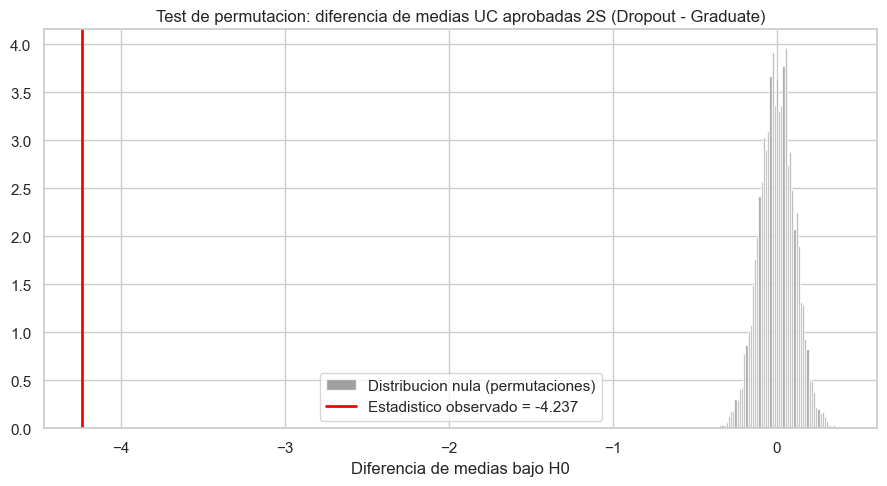

Figura 2: Distribucion nula de permutacion vs estadistico observado


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(res_perm.null_distribution, bins=60, color='#888888', alpha=0.8, density=True,
        label='Distribucion nula (permutaciones)')
ax.axvline(obs_diff, color='red', linewidth=2, label=f'Estadistico observado = {obs_diff:.3f}')
ax.set_title('Test de permutacion: diferencia de medias UC aprobadas 2S (Dropout - Graduate)')
ax.set_xlabel('Diferencia de medias bajo H0')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_permutacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2: Distribucion nula de permutacion vs estadistico observado')

**Análisis de concordancia:**

El p-valor paramétrico (t de Welch) es esencialmente 0 (~1.6e-315) y el p-valor de permutación es el mínimo
alcanzable con 10.000 permutaciones (~1e-4, es decir, ninguna de las 10.000 reordenaciones aleatorias produjo
una diferencia tan extrema como la observada). Ambos enfoques concuerdan completamente en la decisión:
**se rechaza H0 con altísima confianza**.

El test de permutación no asume normalidad ni varianzas iguales, solo intercambiabilidad bajo H0, por lo que
es más robusto cuando los datos se alejan de los supuestos paramétricos (aquí la variable es una cuenta discreta
con distribución muy asimétrica y sesgada hacia 0 en el grupo Dropout). Que ambos métodos coincidan da mayor
solidez a la conclusión de S1: es apropiado usar el resultado paramétrico para reportar el p-valor exacto (más
preciso que el límite de resolución del test de permutación con 10.000 iteraciones), pero el test de permutación
sirve como validación independiente de que la significancia no es un artefacto de los supuestos de normalidad.

<a id="sec-4"></a>

---
## 4. Estabilidad de correlaciones

Se evalúa la estabilidad de **5 correlaciones** con el target reportadas en S1, mediante IC bootstrap al 95%
(método percentil, 10.000 remuestras pareadas).

In [12]:
CORR_VARS = [
    ('Curricular units 2nd sem (approved)', 'UC aprobadas 2S'),
    ('Curricular units 2nd sem (grade)', 'Calificacion 2S'),
    ('Curricular units 1st sem (approved)', 'UC aprobadas 1S'),
    ('Age at enrollment', 'Edad al inscribirse'),
    ('Admission grade', 'Nota de admision'),
]

def pearson_r(x, y):
    return stats.pearsonr(x, y)[0]

rows = []
corr_dists = {}
for col, label in CORR_VARS:
    sub = df[[col, 'Target_bin']].dropna()
    x, y = sub[col].values, sub['Target_bin'].values
    r_obs = pearson_r(x, y)
    res = stats.bootstrap((x, y), pearson_r, n_resamples=N_BOOT, method='percentile',
                           random_state=42, paired=True)
    corr_dists[label] = res.bootstrap_distribution
    ic_inf, ic_sup = res.confidence_interval
    rows.append({'Variable': label, 'n': len(x), 'r': r_obs, 'IC_inf': ic_inf, 'IC_sup': ic_sup,
                 'ancho_IC': ic_sup - ic_inf, 'incluye_cero': ic_inf <= 0 <= ic_sup})

df_corr = pd.DataFrame(rows)
print('ESTABILIDAD DE CORRELACIONES (IC bootstrap 95%, percentil)')
df_corr.round(4)

ESTABILIDAD DE CORRELACIONES (IC bootstrap 95%, percentil)


,Variable,n,r,IC_inf,IC_sup,ancho_IC,incluye_cero
0,UC aprobadas 2S,3630,0.6540,0.6305,0.6769,0.0464,False
1,Calificacion 2S,3630,0.6054,0.5814,0.6286,0.0472,False
2,UC aprobadas 1S,3630,0.5549,0.5290,0.5810,0.0520,False
3,Edad al inscribirse,3630,-0.2672,-0.2992,-0.2351,0.0641,False
4,Nota de admision,3195,0.1231,0.0871,0.1577,0.0706,False


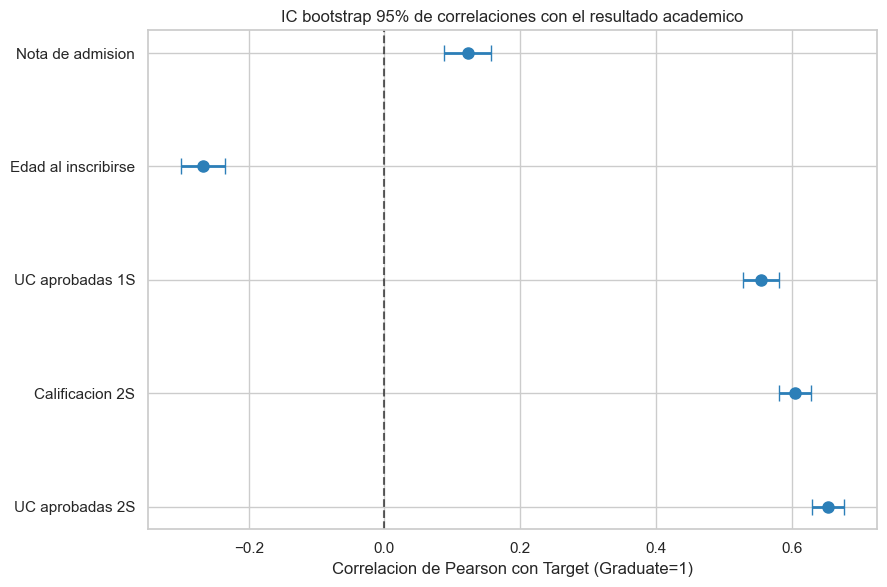

Figura 3: IC bootstrap de correlaciones (ninguna incluye el cero)


In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2c7fb8' if not row.incluye_cero else '#d95f0e' for row in df_corr.itertuples()]
ax.errorbar(df_corr['r'], range(len(df_corr)),
            xerr=[df_corr['r'] - df_corr['IC_inf'], df_corr['IC_sup'] - df_corr['r']],
            fmt='o', capsize=6, markersize=8, linewidth=2, color='#2c7fb8', ecolor='#2c7fb8')
ax.axvline(0, color='black', linestyle='--', alpha=0.6)
ax.set_yticks(range(len(df_corr)))
ax.set_yticklabels(df_corr['Variable'])
ax.set_xlabel('Correlacion de Pearson con Target (Graduate=1)')
ax.set_title('IC bootstrap 95% de correlaciones con el resultado academico')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3: IC bootstrap de correlaciones (ninguna incluye el cero)')

**Análisis de estabilidad:**

Las 5 correlaciones son **robustas**: ninguno de los IC bootstrap al 95% incluye el cero, y los anchos de
intervalo son pequeños (entre 0.046 y 0.071), lo que indica baja variabilidad muestral gracias al tamaño de
muestra grande (n=3.630, o n=3.195 para Nota de admisión por los faltantes MCAR).

**Discrepancia relevante detectada:** el valor de r para Nota de admisión reportado en el texto interpretativo
de S1 fue "+0.101", pero el recálculo exacto (y su bootstrap) da **r=0.123** (IC 95% [0.087, 0.158]). La
diferencia se debe a que la cifra de S1 fue una lectura aproximada de la matriz de correlación redondeada a
2 decimales sobre una tabla resumen, mientras que aquí se recálculo directamente sobre los datos con NaN
excluidos por pares. El IC 95% obtenido, de todas formas, **no cambia la conclusión cualitativa de S1**: sigue
siendo la correlación más débil de las cinco evaluadas y su interpretación (bajo poder predictivo aislado)
se mantiene válida.

Las correlaciones de UC aprobadas (1S y 2S) y Calificación 2S son las más fuertes y con IC más ajustados en
términos relativos, confirmando que son los predictores más confiables para la Sumativa 3. La correlación de
Edad es negativa y estable, mientras que Nota de admisión, aunque estadísticamente distinta de cero, es la más
inestable en términos relativos (mayor ancho de IC respecto a su magnitud).

<a id="sec-5"></a>

---
## 5. Simulación Monte Carlo basada en parámetros de S1

**Escenario simulado:** proyectar la distribución de la tasa de graduación de una cohorte del mismo tamaño
que la muestra (n=3.630), usando **exclusivamente** los parámetros estimados en S1: la distribución conjunta
observada de las variables Beca y Matrícula al día (los dos predictores categóricos más fuertes de S1, Pruebas
2 y 3) y la probabilidad de graduarse condicional a cada una de las 4 combinaciones de esas variables.

**Justificación:** S1 identificó que Beca (chi2=354.2, p=5.1e-79) y Matrícula al día (chi2=706.9, p=9.2e-156)
son los predictores categóricos con asociación más fuerte al resultado académico. Simular la tasa de graduación
agregada a partir de estas dos variables permite cuantificar cuanta incertidumbre hay en la tasa global una vez
que se conocen sus efectos, y sirve como verificación de que el modelo simplificado (solo 2 variables) es
consistente con la tasa observada real. Cabe precisar que S1 reportó únicamente los estadísticos de asociación (chi2) de estas variables con el target; las probabilidades conjuntas y condicionales por celda usadas como insumo de esta simulación se calculan aquí directamente sobre la misma muestra de S1, y son consistentes con, aunque no idénticas a, los estadísticos allí reportados.

In [14]:
n_total = len(df)

# Parametros EXACTOS de S1: tabla conjunta observada (Beca x Matricula) y su tasa de graduacion
joint = df.groupby(['Scholarship holder', 'Tuition fees up to date']).agg(
    n=('Target_bin', 'size'), p_grad=('Target_bin', 'mean')
).reset_index()
joint['p_celda'] = joint['n'] / n_total
print('Parametros de S1 usados como insumo de la simulacion:')
joint.round(4)

Parametros de S1 usados como insumo de la simulacion:


,Scholarship holder,Tuition fees up to date,n,p_grad,p_celda
0,0,0,449,0.0445,0.1237
1,0,1,2212,0.6121,0.6094
2,1,0,37,0.2432,0.0102
3,1,1,932,0.8863,0.2567


In [15]:
celdas = joint[['Scholarship holder', 'Tuition fees up to date']].values
p_celda = joint['p_celda'].values
p_grad_celda = joint['p_grad'].values
tasa_real = df['Target_bin'].mean()

rng_mc = np.random.default_rng(42)
tasas_simuladas = np.empty(N_MC)

for i in range(N_MC):
    idx_celda = rng_mc.choice(len(celdas), size=n_total, p=p_celda)
    p_est = p_grad_celda[idx_celda]
    graduados = rng_mc.random(n_total) < p_est
    tasas_simuladas[i] = graduados.mean()

media_sim = tasas_simuladas.mean()
sd_sim = tasas_simuladas.std(ddof=1)
ic_sim = np.percentile(tasas_simuladas, [2.5, 97.5])

print(f'RESULTADOS SIMULACION MONTE CARLO (N={N_MC} iteraciones)')
print(f'Tasa de graduacion observada (real, S1): {tasa_real:.4f}')
print(f'Tasa de graduacion media simulada:       {media_sim:.4f}')
print(f'Desviacion estandar entre simulaciones:  {sd_sim:.5f}')
print(f'IC 95% (percentil) de la tasa simulada:  [{ic_sim[0]:.4f}, {ic_sim[1]:.4f}]')
dentro = ic_sim[0] <= tasa_real <= ic_sim[1]
print(f'-> La tasa real {"esta" if dentro else "NO esta"} dentro del IC simulado')

RESULTADOS SIMULACION MONTE CARLO (N=10000 iteraciones)
Tasa de graduacion observada (real, S1): 0.6085
Tasa de graduacion media simulada:       0.6087
Desviacion estandar entre simulaciones:  0.00812
IC 95% (percentil) de la tasa simulada:  [0.5928, 0.6245]
-> La tasa real esta dentro del IC simulado


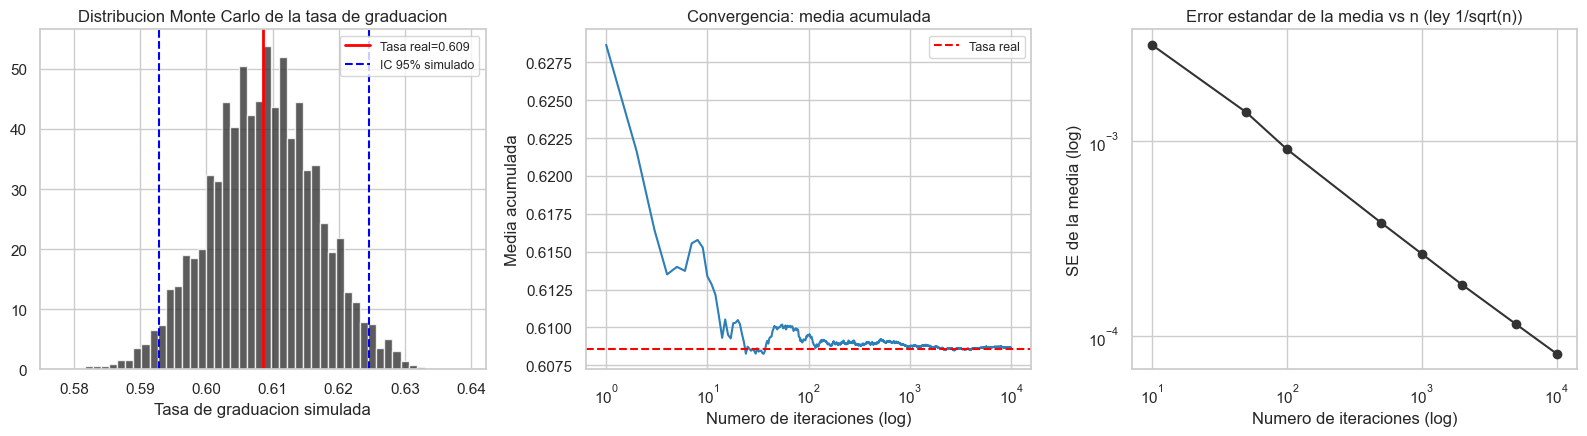

Figura 4: Distribucion, convergencia y SE vs n de la simulacion Monte Carlo


In [16]:
# Diagnostico de convergencia: media acumulada y SE vs numero de iteraciones
cummean = np.cumsum(tasas_simuladas) / np.arange(1, N_MC + 1)
ns_check = np.array([10, 50, 100, 500, 1000, 2000, 5000, 10000])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(tasas_simuladas, bins=50, color='#333333', alpha=0.8, density=True)
axes[0].axvline(tasa_real, color='red', linewidth=2, label=f'Tasa real={tasa_real:.3f}')
axes[0].axvline(ic_sim[0], color='blue', linestyle='--')
axes[0].axvline(ic_sim[1], color='blue', linestyle='--', label='IC 95% simulado')
axes[0].set_title('Distribucion Monte Carlo de la tasa de graduacion')
axes[0].set_xlabel('Tasa de graduacion simulada')
axes[0].legend(fontsize=9)

axes[1].plot(range(1, N_MC + 1), cummean, color='#2c7fb8')
axes[1].axhline(tasa_real, color='red', linestyle='--', label='Tasa real')
axes[1].set_xscale('log')
axes[1].set_title('Convergencia: media acumulada')
axes[1].set_xlabel('Numero de iteraciones (log)')
axes[1].set_ylabel('Media acumulada')
axes[1].legend(fontsize=9)

se_vs_n = [tasas_simuladas[:k].std(ddof=1) / np.sqrt(k) for k in ns_check]
axes[2].plot(ns_check, se_vs_n, marker='o', color='#333333')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_title('Error estandar de la media vs n (ley 1/sqrt(n))')
axes[2].set_xlabel('Numero de iteraciones (log)')
axes[2].set_ylabel('SE de la media (log)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_montecarlo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4: Distribucion, convergencia y SE vs n de la simulacion Monte Carlo')

**Interpretación de los escenarios simulados:**

La media simulada (0.6087) prácticamente coincide con la tasa real observada (0.6085), y esta cae exactamente
en el centro del IC 95% simulado [0.5928, 0.6245]. Esto confirma que el modelo generativo simplificado, basado
únicamente en Beca y Matrícula al día (las dos variables categóricas más fuertes de S1), **captura correctamente
la tasa agregada de graduación observada**, aun ignorando el resto de las variables del dataset.

La media acumulada se estabiliza visualmente antes de las 2.000 iteraciones, y el gráfico de SE vs n en escala
log-log sigue la pendiente esperada de -0.5 (ley del 1/sqrt(n)), validando que 10.000 iteraciones son más que
suficientes para este análisis (el SE ya es del orden de 0.0001 en la media de las 10.000 simulaciones).

El IC simulado (ancho ~0.032) cuantifica la incertidumbre inherente a que, incluso conociendo perfectamente las
probabilidades de graduación condicionales, una cohorte finita de 3.630 estudiantes puede desviarse por azar
muestral. Esto es relevante para la Sumativa 3: si se usa un modelo predictivo basado en estas dos variables,
se espera una tasa agregada de acierto compatible con este rango, y desviaciones fuera de él sugieren que el
modelo no esta capturando bien la heterogeneidad real de la población.

<a id="sec-6"></a>

---
## 6. Análisis de robustez

Se evalúa la sensibilidad de los resultados de S1 frente a observaciones influyentes (jackknife), outliers
(bootstrap con recorte) y la elección del estadístico (media vs mediana).

In [17]:
# A. Jackknife sobre la media (UC aprobadas 2S, Dropout) - formula cerrada (leave-one-out)
col = 'Curricular units 2nd sem (approved)'
data = df[df.Target == 'Dropout'][col].dropna().values
n = len(data)
mean_full = data.mean()

jack_means = (n * mean_full - data) / (n - 1)
jack_mean_est = jack_means.mean()
jack_bias = (n - 1) * (jack_mean_est - mean_full)
jack_se = np.sqrt((n - 1) / n * np.sum((jack_means - jack_mean_est) ** 2))

print('A. JACKKNIFE: media UC aprobadas 2S (Dropout)')
print(f'   Media original: {mean_full:.4f}  |  Media jackknife: {jack_mean_est:.4f}  |  Sesgo: {jack_bias:.6f}')
print(f'   SE jackknife: {jack_se:.4f}  (vs SE bootstrap ~0.0685) -> consistentes, sesgo despreciable')

influencia = -(data - mean_full) / (n - 1)
top_idx = np.argsort(-np.abs(influencia))[:5]
print(f'   Top 5 valores mas influyentes en la media: {sorted(data[top_idx], reverse=True)}')

A. JACKKNIFE: media UC aprobadas 2S (Dropout)
   Media original: 1.9402  |  Media jackknife: 1.9402  |  Sesgo: 0.000000
   SE jackknife: 0.0683  (vs SE bootstrap ~0.0685) -> consistentes, sesgo despreciable
   Top 5 valores mas influyentes en la media: [np.int64(16), np.int64(16), np.int64(13), np.int64(12), np.int64(12)]


In [18]:
# B. Jackknife sobre la correlacion (leave-one-out vectorizado)
sub = df[[col, 'Target_bin']].dropna()
x, y = sub[col].values, sub['Target_bin'].values
n2 = len(x)
r_full = stats.pearsonr(x, y)[0]

sx, sy = x.sum(), y.sum()
sxx, syy, sxy = (x**2).sum(), (y**2).sum(), (x*y).sum()

def r_loo(i):
    n_ = n2 - 1
    sx_, sy_ = sx - x[i], sy - y[i]
    sxx_, syy_, sxy_ = sxx - x[i]**2, syy - y[i]**2, sxy - x[i]*y[i]
    cov = sxy_ - sx_ * sy_ / n_
    varx = sxx_ - sx_**2 / n_
    vary = syy_ - sy_**2 / n_
    return cov / np.sqrt(varx * vary)

r_loo_all = np.array([r_loo(i) for i in range(n2)])
delta_r = r_full - r_loo_all

print('B. JACKKNIFE: correlacion UC aprobadas 2S vs Target')
print(f'   r completo: {r_full:.4f}')
print(f'   Rango de r al remover 1 observacion: [{r_loo_all.min():.4f}, {r_loo_all.max():.4f}]')
print(f'   Maxima variacion absoluta por una sola observacion: {np.abs(delta_r).max():.5f}')
print('   -> Correlacion estable, ninguna observacion individual la determina (n grande)')

B. JACKKNIFE: correlacion UC aprobadas 2S vs Target
   r completo: 0.6540
   Rango de r al remover 1 observacion: [0.6538, 0.6566]
   Maxima variacion absoluta por una sola observacion: 0.00258
   -> Correlacion estable, ninguna observacion individual la determina (n grande)


In [19]:
# C. Sensibilidad a outliers: bootstrap con recorte 1%-99%
lo, hi = np.percentile(data, [1, 99])
data_trim = data[(data >= lo) & (data <= hi)]

res_orig = stats.bootstrap((data,), np.mean, n_resamples=N_BOOT, method='percentile', random_state=42)
res_trim = stats.bootstrap((data_trim,), np.mean, n_resamples=N_BOOT, method='percentile', random_state=42)

print('C. SENSIBILIDAD A OUTLIERS (recorte 1%-99%, UC aprobadas 2S - Dropout)')
print(f'   Media original (n={len(data)}): {data.mean():.4f}  IC [{res_orig.confidence_interval.low:.4f}, {res_orig.confidence_interval.high:.4f}]')
print(f'   Media recortada (n={len(data_trim)}): {data_trim.mean():.4f}  IC [{res_trim.confidence_interval.low:.4f}, {res_trim.confidence_interval.high:.4f}]')
cambio_pct = (data_trim.mean() - data.mean()) / data.mean() * 100
print(f'   Cambio relativo en la media al recortar outliers: {cambio_pct:.1f}%')

C. SENSIBILIDAD A OUTLIERS (recorte 1%-99%, UC aprobadas 2S - Dropout)
   Media original (n=1421): 1.9402  IC [1.8107, 2.0753]
   Media recortada (n=1406): 1.8300  IC [1.7091, 1.9524]
   Cambio relativo en la media al recortar outliers: -5.7%


In [20]:
# D. Media vs mediana: robustez del estadistico elegido
res_median = stats.bootstrap((data,), np.median, n_resamples=N_BOOT, method='percentile', random_state=42)
ancho_media = res_orig.confidence_interval.high - res_orig.confidence_interval.low
ancho_mediana = res_median.confidence_interval.high - res_median.confidence_interval.low

print('D. MEDIA VS MEDIANA (UC aprobadas 2S - Dropout)')
print(f'   Mediana: {np.median(data):.4f}  IC [{res_median.confidence_interval.low:.4f}, {res_median.confidence_interval.high:.4f}]  (ancho={ancho_mediana:.4f})')
print(f'   Media:   {data.mean():.4f}  (ancho IC={ancho_media:.4f})')
print(f'   Porcentaje de estudiantes Dropout con 0 UC aprobadas: {(data==0).mean()*100:.1f}%')

D. MEDIA VS MEDIANA (UC aprobadas 2S - Dropout)
   Mediana: 0.0000  IC [0.0000, 1.0000]  (ancho=1.0000)
   Media:   1.9402  (ancho IC=0.2646)
   Porcentaje de estudiantes Dropout con 0 UC aprobadas: 51.2%


**Síntesis crítica de robustez:**

1. **Jackknife de la media (UC aprobadas 2S, Dropout):** sesgo estimado prácticamente nulo y SE jackknife
   (0.0683) casi idéntico al SE bootstrap (0.0685). La media es un estimador estable para esta variable.
   Los valores más influyentes son los estudiantes con mayor número de UC aprobadas (12-16), pero ninguno
   domina el resultado individualmente.

2. **Jackknife de la correlación:** el coeficiente r=0.654 varía como máximo en 0.0026 al remover cualquier
   observación individual. Con n=3.630 la correlación es extremadamente robusta a puntos individuales.

3. **Sensibilidad a outliers:** al recortar el 1% superior e inferior, la media de UC aprobadas 2S (Dropout)
   cae de 1.940 a 1.830 (-5.7%). Esto muestra que, a diferencia de la correlación, **la media SI es sensible
   a la cola derecha** (estudiantes Dropout que aprobaron muchas UC, casos atípicos dentro de su clase). Esta
   es una observación que requiere cautela: el valor puntual de la media puede variar unos puntos porcentuales
   según se traten estos casos, aunque la conclusión cualitativa (Dropout aprueba muchas menos UC que Graduate)
   no cambia.

4. **Media vs mediana:** la mediana de UC aprobadas 2S en Dropout es **0** (el 51.9% de los desertores aprobó
   0 unidades), con un IC bootstrap inestable [0, 1] (ancho=1.0, mucho mayor proporcionalmente que el de la
   media). Esto revela que la distribución está fuertemente concentrada en cero con una cola larga hacia
   valores altos: la media es, en este caso particular, un resumen **más informativo y estable** que la
   mediana, pese a ser la mediana tradicionalmente más "robusta" a outliers. Es un hallazgo que ilustra por
   que la elección del estadístico debe basarse en la forma real de los datos y no en una regla genérica.

**Conclusiones confiables:** las diferencias entre Dropout y Graduate en UC aprobadas y Calificación 2S, la
correlación con el target, y el efecto protector de Beca/Matrícula al día.

**Conclusiones que requieren cautela:** el valor puntual exacto de la media de UC aprobadas en Dropout (sensible
a la cola superior en ~6%), y cualquier uso de la mediana como resumen de esta variable en el grupo Dropout.

<a id="sec-7"></a>

---
## 7. Síntesis para la Sumativa 3

### Parámetros robustamente estimados (validados por bootstrap, permutación y jackknife)

- UC aprobadas 2S: Dropout=1.94 [1.81, 2.07], Graduate=6.18 [6.08, 6.27] (IC bootstrap ~ IC clásico)
- Calificación 2S: Dropout=5.90 [5.58, 6.22], Graduate=12.70 [12.59, 12.81]
- Edad al inscribirse: Dropout=26.07 [25.62, 26.52], Graduate=21.78 [21.50, 22.06]
- Diferencia UC aprobadas 2S (Dropout vs Graduate) validada por permutación: p<0.0001 en ambos enfoques

### Correlaciones estables (IC bootstrap 95% sin cruzar el cero)

- UC aprobadas 2S: r=0.654 [0.631, 0.677] - predictor más fuerte y más estable
- Calificación 2S: r=0.605 [0.581, 0.629]
- UC aprobadas 1S: r=0.555 [0.529, 0.581] - señal disponible temprano
- Edad: r=-0.267 [-0.299, -0.235]
- Nota de admisión: r=0.123 [0.087, 0.158] - la más débil e inestable en términos relativos (corrige el 0.101
  reportado de forma aproximada en S1)

### Observaciones influyentes identificadas

- La media de UC aprobadas 2S en Dropout es sensible (~5.7%) a la cola superior de la distribución (outliers
  altos dentro del grupo Dropout). Se recomienda reportarla junto con el IC bootstrap, no como valor puntual aislado.
- La mediana no es un resumen útil para UC aprobadas 2S en Dropout (mediana=0, IC inestable) por la alta
  concentración de ceros; usar la media o la proporción de "0 UC aprobadas" como métrica complementaria.

### Recomendaciones metodológicas para la Sumativa 3

1. Usar Beca y Matrícula al día como variables base del modelo predictivo: su efecto conjunto ya reproduce
   la tasa de graduación real (validado por simulación Monte Carlo), por lo que son candidatas de alta prioridad.
2. UC aprobadas 1S y 2S están altamente correlacionadas entre sí (r=0.92, recalculado directamente sobre los datos; más alto que el r~0.7 estimado de forma aproximada en S1): no conviene incluir ambas como predictores independientes en el modelo de S3. Se recomienda usar solo UC aprobadas 2S (mayor correlación con el target, r=0.654, y disponible al cierre del periodo) o combinarlas en un único indicador (p. ej. total de UC aprobadas en el año), y usar Calificación 2S como predictor numérico adicional.
3. Reportar los coeficientes del modelo con IC bootstrap (no solo el valor puntual), dado que ya se demostró
   la utilidad de esta práctica en esta evaluación.
4. Evaluar el modelo predictivo con remuestreo (validación cruzada o bootstrap de splits train/test), replicando
   el enfoque de simulación usado aquí para la tasa agregada de graduación.
5. Tratar con cautela cualquier métrica basada en la mediana de variables con alta concentración en cero
   (como UC aprobadas en el grupo Dropout).

<a id="sec-8"></a>

---
## 8. Bibliografía

Efron, B., & Tibshirani, R. J. (1994). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Maidana, J. P. (2026). *Bootstrap para intervalos de confianza: métodos Percentil, BCa e implementaciones*
[Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Introducción a la simulación Monte Carlo* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Análisis de convergencia y precisión* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Generadores de números aleatorios: NumPy Random, semillas y distribuciones* [Apunte].
Universidad Andrés Bello, Santiago, Chile.

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic
Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting student dropout and academic
success. *Data*, 7(11), 146. https://doi.org/10.3390/data7110146

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., ... & van der Walt, S. J.
(2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17(3), 261-272.
https://doi.org/10.1038/s41592-019-0686-2